In [118]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import requests

In [119]:
world = gpd.read_file("countries.json").set_index('sovereignt')

#### Getting country-level data

In [120]:
european_gas_consumption_2024_twh = {
    # --- EU27 countries (source: Eurostat nrg_cb_gasm, 2024) ---
    "Germany":      838.0,   # 3,016,962 TJ (exact from Eurostat)
    "Italy":        654.8,   # 2,357,157 TJ (exact from Eurostat)
    "France":       363.7,   # 1,309,178 TJ (exact from Eurostat)
    "Netherlands":  310.0,   # ~1,116,000 TJ (Eurostat database)
    "Spain":        310.0,   # ~1,116,000 TJ (Eurostat database)
    "Poland":       207.0,   # ~745,000 TJ
    "Belgium":      155.0,   # ~558,000 TJ
    "Romania":      105.0,   # ~378,000 TJ
    "Hungary":       90.0,   # ~324,000 TJ
    "Czechia":       78.0,   # ~281,000 TJ
    "Austria":       77.0,   # ~277,000 TJ
    "Greece":        68.0,   # ~245,000 TJ (↑31.3% YoY per Eurostat)
    "Ireland":       53.0,   # ~191,000 TJ
    "Slovakia":      49.0,   # ~176,000 TJ
    "Portugal":      44.0,   # ~158,000 TJ (↓16.7% YoY per Eurostat)
    "Denmark":       28.0,   # ~101,000 TJ
    "Bulgaria":      28.0,   # ~101,000 TJ
    "Finland":       18.0,   # ~65,000 TJ (↑9.5% YoY per Eurostat)
    "Croatia":       25.0,   # ~90,000 TJ (↓5.4% YoY per Eurostat)
    "Lithuania":     20.0,   # ~72,000 TJ (↑9.2% YoY per Eurostat)
    "Sweden":        11.0,   # ~40,000 TJ
    "Latvia":        11.0,   # ~40,000 TJ
    "Luxembourg":     7.0,   # ~25,000 TJ
    "Slovenia":       8.5,   # ~31,000 TJ
    "Estonia":        4.5,   # ~16,000 TJ
    "Malta":          0.7,   # ~2,500 TJ (↓7.1% YoY per Eurostat)
    "Cyprus":         0.0,   # no significant gas consumption
    # --- Non-EU European countries ---
    "United Kingdom": 690.0, # ~2,484,000 TJ (Bruegel / DESNZ Energy Trends)
    "Norway":          5.0,  # domestic consumption only (major exporter)
    "Switzerland":    33.0,  # ~119,000 TJ (Swiss Federal Office of Energy)
}

In [121]:
"""
European natural gas consumption 2024 by country (TWh).

Fetches from Eurostat API (nrg_cb_gasm dataset).
Sums monthly values (Jan-Dec) to get annual totals.

Source: Eurostat, dataset nrg_cb_gasm
        Inland consumption, observed (IC_OBS)
        Natural gas (G3000), TJ_GCV -> converted to TWh (/3600)
"""

import requests

# -- Config --
DATASET = "nrg_cb_gasm"
SIEC = "G3000"
UNIT = "TJ_GCV"
NRG_BAL = "IC_OBS"
YEAR = 2024
BASE_URL = f"https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/{DATASET}"

EU27_CODES = [
    "AT", "BE", "BG", "CY", "CZ", "DE", "DK", "EE", "EL", "ES",
    "FI", "FR", "HR", "HU", "IE", "IT", "LT", "LU", "LV", "MT",
    "NL", "PL", "PT", "RO", "SE", "SI", "SK",
]
EXTRA_CODES = ["UK", "NO", "CH"]

COUNTRY_NAMES = {
    "AT": "Austria", "BE": "Belgium", "BG": "Bulgaria", "CY": "Cyprus",
    "CZ": "Czechia", "DE": "Germany", "DK": "Denmark", "EE": "Estonia",
    "EL": "Greece", "ES": "Spain", "FI": "Finland", "FR": "France",
    "HR": "Croatia", "HU": "Hungary", "IE": "Ireland", "IT": "Italy",
    "LT": "Lithuania", "LU": "Luxembourg", "LV": "Latvia", "MT": "Malta",
    "NL": "Netherlands", "PL": "Poland", "PT": "Portugal", "RO": "Romania",
    "SE": "Sweden", "SI": "Slovenia", "SK": "Slovakia",
    "UK": "United Kingdom", "NO": "Norway", "CH": "Switzerland",
}


def _parse_json_stat(js: dict) -> dict:
    """
    Parse Eurostat JSON-stat response.
    Returns {(geo_code, time_code): TJ_value}.
    """
    values = js.get("value", {})
    if not values:
        return {}

    dims = js["id"]
    sizes = js["size"]

    geo_cats = js["dimension"]["geo"]["category"]["index"]
    time_cats = js["dimension"]["time"]["category"]["index"]
    pos_to_geo = {v: k for k, v in geo_cats.items()}
    pos_to_time = {v: k for k, v in time_cats.items()}

    geo_dim_idx = dims.index("geo")
    time_dim_idx = dims.index("time")

    # Compute strides for each dimension
    strides = {}
    for d_idx in range(len(dims)):
        s = 1
        for j in range(d_idx + 1, len(dims)):
            s *= sizes[j]
        strides[d_idx] = s

    result = {}
    for flat_str, val in values.items():
        if val is None:
            continue
        flat = int(flat_str)
        gp = (flat // strides[geo_dim_idx]) % sizes[geo_dim_idx]
        tp = (flat // strides[time_dim_idx]) % sizes[time_dim_idx]
        gc = pos_to_geo.get(gp)
        tc = pos_to_time.get(tp)
        if gc and tc:
            result[(gc, tc)] = float(val)
    return result


def _fetch_country_annual(geo: str, months: list) -> tuple:
    """Fetch all months for one country. Returns (total_TJ, n_months) or (None, 0)."""
    time_params = "&".join(f"time={t}" for t in months)
    url = (
        f"{BASE_URL}?geo={geo}&{time_params}"
        f"&siec={SIEC}&unit={UNIT}&nrg_bal={NRG_BAL}"
        f"&lang=EN&format=JSON"
    )
    try:
        r = requests.get(url, timeout=60)
        if r.status_code == 200:
            parsed = _parse_json_stat(r.json())
            total = sum(parsed.values())
            n = len(parsed)
            if total > 0:
                return total, n
        return None, 0
    except Exception:
        return None, 0


def fetch_from_eurostat(year: int = 2024) -> dict:
    """
    Fetch country-level natural gas inland consumption from Eurostat.
    Sums all 12 monthly values to get annual total.
    Returns {country_name: TWh}.
    """
    # Eurostat API time format: "YYYY-MM"
    months = [f"{year}-{m:02d}" for m in range(1, 13)]
    time_params = "&".join(f"time={t}" for t in months)

    results = {}  # geo_code -> annual TJ

    # -- Step 1: Batch fetch EU27 (all countries x 12 months) --
    geo_params = "&".join(f"geo={c}" for c in EU27_CODES)
    url = (
        f"{BASE_URL}?{geo_params}&{time_params}"
        f"&siec={SIEC}&unit={UNIT}&nrg_bal={NRG_BAL}"
        f"&lang=EN&format=JSON"
    )
    print(f"Fetching EU27 ({len(EU27_CODES)} countries x 12 months)...")
    batch_ok = False
    try:
        r = requests.get(url, timeout=120)
        if r.status_code == 200:
            parsed = _parse_json_stat(r.json())
            for (gc, tc), val in parsed.items():
                results[gc] = results.get(gc, 0.0) + val
            print(f"  OK: got data for {len(results)} countries")
            for gc in EU27_CODES:
                n_months = sum(1 for (g, t) in parsed if g == gc)
                if 0 < n_months < 12:
                    print(f"  Warning: {COUNTRY_NAMES[gc]} only {n_months}/12 months")
            batch_ok = True
        else:
            print(f"  Failed ({r.status_code}), falling back to per-country...")
    except Exception as e:
        print(f"  Exception: {e}, falling back to per-country...")

    if not batch_ok:
        for code in EU27_CODES:
            total, n = _fetch_country_annual(code, months)
            if total:
                results[code] = total
                print(f"  {COUNTRY_NAMES[code]:20s} {total:>12,.0f} TJ = {total/3600:>8.1f} TWh ({n}m)")
            else:
                print(f"  {COUNTRY_NAMES[code]:20s} no data")

    # -- Step 2: Fetch non-EU countries individually --
    print(f"\nFetching non-EU countries (UK, NO, CH)...")
    for code in EXTRA_CODES:
        total, n = _fetch_country_annual(code, months)
        if total:
            results[code] = total
            print(f"  {COUNTRY_NAMES[code]:20s} {total:>12,.0f} TJ = {total/3600:>8.1f} TWh ({n}m)")
        else:
            print(f"  {COUNTRY_NAMES[code]:20s} no data in nrg_cb_gasm")

    # -- Convert to TWh --
    out = {}
    for code, tj in results.items():
        name = COUNTRY_NAMES.get(code, code)
        out[name] = round(tj / 3600.0, 1)

    return out


# -- Run --
if __name__ == "__main__":
    print(f"European natural gas inland consumption {YEAR}")
    print(f"Source: Eurostat nrg_cb_gasm, IC_OBS, G3000, TJ_GCV")
    print("=" * 55)
    print()

    data = fetch_from_eurostat(YEAR)

    if data:
        eu27 = {k: v for k, v in data.items()
                if k not in ("United Kingdom", "Norway", "Switzerland")}
        extra = {k: v for k, v in data.items()
                 if k in ("United Kingdom", "Norway", "Switzerland")}

        print(f"\n{'='*55}")
        print(f"{'Country':<25} {'TWh':>8}")
        print(f"{'-'*55}")

        print("  EU27:")
        for k, v in sorted(eu27.items(), key=lambda x: -x[1]):
            print(f"  {k:<23} {v:>8.1f}")
        print(f"  {'-'*53}")
        print(f"  {'EU27 Total':<23} {sum(eu27.values()):>8.1f}")

        if extra:
            print(f"\n  Non-EU:")
            for k, v in sorted(extra.items(), key=lambda x: -x[1]):
                print(f"  {k:<23} {v:>8.1f}")

        print(f"\n  {'Grand Total':<23} {sum(data.values()):>8.1f}")

        # Print copy-paste dict
        print(f"\n{'='*55}")
        print("# Copy-paste Python dict:")
        print(f"# Source: Eurostat nrg_cb_gasm, IC_OBS, {YEAR}, TJ_GCV -> TWh")
        print(f"european_gas_consumption_{YEAR}_twh = {{")
        for k, v in sorted(data.items(), key=lambda x: -x[1]):
            print(f'    "{k}": {v},')
        print("}")
    else:
        print("No data retrieved.")

European natural gas inland consumption 2024
Source: Eurostat nrg_cb_gasm, IC_OBS, G3000, TJ_GCV

Fetching EU27 (27 countries x 12 months)...
  OK: got data for 27 countries

Fetching non-EU countries (UK, NO, CH)...


  United Kingdom       no data in nrg_cb_gasm
  Norway                    186,747 TJ =     51.9 TWh (12m)
  Switzerland          no data in nrg_cb_gasm

Country                        TWh
-------------------------------------------------------
  EU27:
  Germany                    837.0
  Italy                      654.8
  France                     355.2
  Spain                      312.0
  Netherlands                294.1
  Poland                     219.6
  Belgium                    153.1
  Romania                    106.0
  Hungary                     91.7
  Austria                     75.9
  Czechia                     74.2
  Greece                      66.6
  Ireland                     55.0
  Slovakia                    47.9
  Portugal                    40.6
  Bulgaria                    30.1
  Croatia                     26.6
  Denmark                     26.2
  Lithuania                   18.9
  Finland                     18.7
  Sweden                       9.8
  Slovenia   

In [122]:
df_countries = pd.Series(data)
df_countries.loc['United Kingdom'] = 206 + 345 + 85
df_countries.loc['Switzerland'] = 26.5
df_countries

Austria            75.9
Belgium           153.1
Bulgaria           30.1
Cyprus              0.0
Czechia            74.2
Germany           837.0
Denmark            26.2
Estonia             3.8
Greece             66.6
Spain             312.0
Finland            18.7
France            355.2
Croatia            26.6
Hungary            91.7
Ireland            55.0
Italy             654.8
Lithuania          18.9
Luxembourg          6.7
Latvia              8.9
Malta               4.0
Netherlands       294.1
Poland            219.6
Portugal           40.6
Romania           106.0
Sweden              9.8
Slovenia            9.5
Slovakia           47.9
Norway             51.9
United Kingdom    636.0
Switzerland        26.5
dtype: float64

In [123]:
import pandas as pd

# Conversion: 1 bcm ≈ 10.55 TWh (gross calorific value)
BCM_TO_TWH = 10.55

# =============================================================================
# DF1: EU-27 + UK gas supply sources, 2024 annual totals
# Source: OIES Quarterly Gas Review Issue 29, Figures 11–12
# =============================================================================
df_supply = pd.DataFrame([
    {"type": "Domestic production", "origin": "UK",           "bcm_2024": 27.1, "twh_2024": 285.9, "lat": 54.00, "lon": -2.00, "coord_note": "UK centroid"},
    {"type": "Domestic production", "origin": "Netherlands",  "bcm_2024":  9.6, "twh_2024": 101.3, "lat": 52.13, "lon":  5.29, "coord_note": "Netherlands centroid"},
    {"type": "Domestic production", "origin": "Romania",      "bcm_2024":  8.6, "twh_2024":  90.7, "lat": 45.94, "lon": 24.97, "coord_note": "Romania centroid"},
    {"type": "Domestic production", "origin": "Rest of EU",   "bcm_2024": 13.2, "twh_2024": 139.3, "lat": 48.00, "lon": 10.00, "coord_note": "Approx. EU27 centroid"},
    {"type": "Pipeline import",    "origin": "Norway",        "bcm_2024": 121.8,"twh_2024": 1285.0,"lat": 53.60, "lon":  7.15, "coord_note": "Dornum, DE (Europipe receiving terminal)"},
    {"type": "Pipeline import",    "origin": "Russia",        "bcm_2024": 32.0, "twh_2024": 337.6, "lat": 42.10, "lon": 27.83, "coord_note": "Strandzha, BG (TurkStream EU entry)"},
    {"type": "Pipeline import",    "origin": "North Africa",  "bcm_2024": 32.2, "twh_2024": 339.7, "lat": 37.65, "lon": 12.59, "coord_note": "Mazara del Vallo, IT (TransMed landfall)"},
    {"type": "Pipeline import",    "origin": "Azerbaijan",    "bcm_2024": 12.3, "twh_2024": 129.8, "lat": 41.08, "lon": 26.36, "coord_note": "Kipoi, GR (TAP/TANAP border crossing)"},
    {"type": "Pipeline import",    "origin": "Other",         "bcm_2024":  0.4, "twh_2024":   4.2, "lat": 48.00, "lon": 10.00, "coord_note": "Generic EU location"},
    {"type": "LNG",                "origin": "Various",       "bcm_2024": 116.3,"twh_2024": 1227.0,"lat": 51.96, "lon":  4.02, "coord_note": "Gate Terminal, Rotterdam, NL"},
])
# =============================================================================
# DF2: EU-27 + UK gas demand by sector, 2024 annual totals
# Source: OIES Quarterly Gas Review Issue 29, Figures 20–22
# =============================================================================
df_demand = pd.DataFrame([
    ("Residential & commercial", 152.0),
    ("Industry",                  83.2),
    ("Power",                    117.9),
], columns=["sector", "bcm_2024"])

df_demand["twh_2024"] = (df_demand["bcm_2024"] * BCM_TO_TWH).round(1)
df_demand = df_demand.set_index('sector')['twh_2024']

#### Getting sectoral consumption data

In [124]:
# --- Eurostat query settings ---
DATASET = "nrg_bal_c"
GEO = "EU27_2020"
TIME = "2024"
SIEC = "G3000"      # Natural gas :contentReference[oaicite:3]{index=3}
UNIT = "TJ"         # Terajoule (energy content basis as provided by the balance)

BCM_TO_TWH = 10.5

# Eurostat balance items (nrg_bal) for your sectoral split :contentReference[oaicite:4]{index=4}
SECTORS = [
    ("Power sector (input to electricity & heat generation)", "TI_EHG_E"),
    ("Residential heating (households)", "FC_OTH_HH_E"),
    ("Services heating (commercial & public services)", "FC_OTH_CP_E"),
    ("Industry heating (energy use)", "FC_IND_E"),
    ("Industry feedstock (non-energy use)", "FC_IND_NE"),
]

BASE_URL = f"https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/{DATASET}"

def fetch_one(nrg_bal_code: str) -> float:
    params = {
        "geo": GEO,
        "time": TIME,
        "siec": SIEC,
        "unit": UNIT,
        "nrg_bal": nrg_bal_code,
        "lang": "EN",
        "format": "JSON",
    }
    r = requests.get(BASE_URL, params=params, timeout=60)
    r.raise_for_status()
    js = r.json()

    # JSON-stat: values are in js["value"], typically a dict {index: value}
    values = js.get("value", {})
    if not values:
        return float("nan")

    # There should be exactly 1 observation given the tight filters
    v = next(iter(values.values()))
    return float(v) if v is not None else float("nan")

rows = []
for sector_label, code in SECTORS:
    tj = fetch_one(code)
    rows.append({
        "sector": sector_label,
        "nrg_bal": code,
        "geo": GEO,
        "time": int(TIME),
        "unit": UNIT,
        "siec": SIEC,
        "value_TJ": tj,
        "value_TWh": tj / 3600.0,   # 1 TWh = 3600 TJ
    })

df = pd.DataFrame(rows)

# Convenience aggregates matching your requested buckets
df_agg_eu = pd.DataFrame([
    {
        "sector": "Power sector",
        "value_TJ": df.loc[df["nrg_bal"].eq("TI_EHG_E"), "value_TJ"].sum(),
    },
    {
        "sector": "Residential + Services heating",
        "value_TJ": df.loc[df["nrg_bal"].isin(["FC_OTH_HH_E", "FC_OTH_CP_E"]), "value_TJ"].sum(),
    },
    {
        "sector": "Industry heating",
        "value_TJ": df.loc[df["nrg_bal"].eq("FC_IND_E"), "value_TJ"].sum(),
    },
    {
        "sector": "Industry feedstock",
        "value_TJ": df.loc[df["nrg_bal"].eq("FC_IND_NE"), "value_TJ"].sum(),
    },
])
df_agg_eu["value_TWh"] = df_agg_eu["value_TJ"] / 3600.0
df_agg_eu["geo"] = GEO
df_agg_eu["time"] = int(TIME)
df_agg_eu["unit"] = "TJ/TWh"
df_agg_eu

# You now have:
# - df: raw-by-balance-item view (with Eurostat codes)
# - df_agg: exactly your 4 sector buckets

,sector,value_TJ,value_TWh,geo,time,unit
0,Power sector,3453718.704,959.366307,EU27_2020,2024,TJ/TWh
1,Residential + Services heating,4073380.347,1131.494541,EU27_2020,2024,TJ/TWh
2,Industry heating,2865468.523,795.963479,EU27_2020,2024,TJ/TWh
3,Industry feedstock,458571.765,127.381046,EU27_2020,2024,TJ/TWh


In [125]:
# Hard-coded dataframe with the specified values
df_agg_uk = pd.DataFrame([
    {
        "sector": "Power sector",
        "value_TJ": np.nan,
        "value_TWh": 206.,
        "geo": "UK",
        "time": 2024,
        "unit": "TJ/TWh"
    },
    {
        "sector": "Residential + Services heating",
        "value_TJ": np.nan,
        "value_TWh": 345,
        "geo": "UK",
        "time": 2024,
        "unit": "TJ/TWh"
    },
    {
        "sector": "Industry heating",
        "value_TJ": np.nan,
        "value_TWh": 85.,
        "geo": "UK",
        "time": 2024,
        "unit": "TJ/TWh"
    },
    {
        "sector": "Industry feedstock",
        "value_TJ": np.nan,
        "value_TWh": 0.,
        "geo": "UK",
        "time": 2024,
        "unit": "TJ/TWh"
    }
])

df_agg_uk

,sector,value_TJ,value_TWh,geo,time,unit
0,Power sector,NaN,206.0,UK,2024,TJ/TWh
1,Residential + Services heating,NaN,345.0,UK,2024,TJ/TWh
2,Industry heating,NaN,85.0,UK,2024,TJ/TWh
3,Industry feedstock,NaN,0.0,UK,2024,TJ/TWh


In [126]:
df_agg_no = pd.DataFrame([
    {
        "sector": "Power sector",
        "value_TJ": np.nan,
        "value_TWh": 0.,  # Not separately reported in SSB data
        "geo": "Norway",
        "time": 2024,
        "unit": "TJ/TWh"
    },
    {
        "sector": "Residential + Services heating",
        "value_TJ": np.nan,
        "value_TWh": 0.,  # Not separately reported in SSB data
        "geo": "Norway",
        "time": 2024,
        "unit": "TJ/TWh"
    },
    {
        "sector": "Industry heating",
        "value_TJ": np.nan,
        "value_TWh": 2.5,  # Manufacturing etc.
        "geo": "Norway",
        "time": 2024,
        "unit": "TJ/TWh"
    },
    {
        "sector": "Industry feedstock",
        "value_TJ": np.nan,
        "value_TWh": 1.5,  # Non energy consumption
        "geo": "Norway",
        "time": 2024,
        "unit": "TJ/TWh"
    }
])

df_agg_ch = pd.DataFrame([
    {
        "sector": "Total",
        "value_TJ": np.nan,
        "value_TWh": 26.5,
        "geo": "Switzerland",
        "time": 2024,
        "unit": "TJ/TWh"
    },
])

# Source notes:
# NORWAY (SSB energy balance table excerpt)
# Natural gas:
#   - Final consumption (11+12): 5.4 TWh
#   - Non energy consumption:    1.5 TWh
#   - Final energy consumption:  3.9 TWh
#   - Manufacturing etc.:        2.5 TWh
#   - Transport:                1.2 TWh
# (All from SSB "Supply and use of energy in Norway by energy product, Energy balance. TWh" for 2024)
# https://www.ssb.no/en/energi-og-industri/energi/statistikk/produksjon-og-forbruk-av-energi-energibalanse-og-energiregnskap  (StatBank table 11561)

# SWITZERLAND (SFOE extract, "Energy Consumption in Switzerland 2024")
# Gas final consumption (2024): 26.522 TWh (95'480 TJ)
# Gas used for district heating & electricity production: 1.825 TWh
# Imports of natural gas (2024): 27.911 TWh (100'480 TJ)
# https://pubdb.bfe.admin.ch/en/publication/download/12195

In [127]:
df = pd.concat([df_agg_eu, df_agg_uk, df_agg_no, df_agg_ch])


sector_colors = {
    "Power sector": "#006400",           # Dark green
    "Residential + Services heating": "#228B22",  # Forest green
    "Industry heating": "#32CD32",       # Lime green
    "Industry feedstock": "#90EE90",     # Light green
    "Total": "#98FB98",                  # Pale green
}

sector_nicenames = {
    "Power sector": "Power\nsector",
    "Residential + Services heating": "Residential +\nServices heating",
    "Industry heating": "Industry\nheating",
    "Industry feedstock": "Industry\nfeedstock",
    "Total": "Total"
}

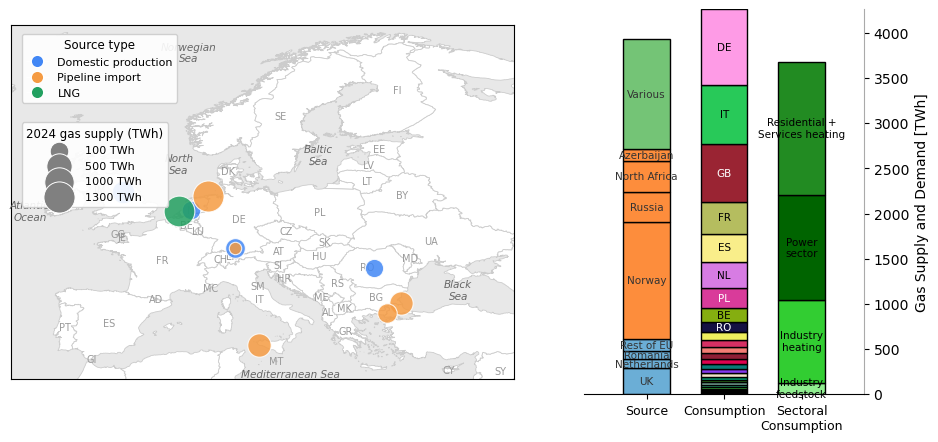

Done.


In [130]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import geopandas as gpd
from matplotlib.colors import to_rgba

# =============================================================================
# DATA — replace these with your real data
# =============================================================================

# --- Assume gdf is your GeoDataFrame with country geometries ---
# It needs at minimum a 'geometry' column and a 'name' column.
# For demo purposes we load Natural Earth:
gdf = world.copy()
# gdf = gdf[gdf['name'] != 'Russia']

# --- Scatter points (dummy) ---
point_colors_map = ['#e63946', '#457b9d', '#e9c46a']  # red, blue, gold
color_labels = ['Category A', 'Category B', 'Category C']

np.random.seed(42)
pts_lon = np.array([2.3, -3.7, 10.4, 14.4, 25.0, 18.1, -1.2, 12.5, 21.0, 28.9])
pts_lat = np.array([48.8, 40.4, 51.2, 50.1, 46.8, 59.3, 53.5, 41.9, 64.1, 41.0])
pts_sizes = np.array([60, 180, 120, 300, 90, 250, 150, 200, 100, 220])
pts_cat = np.array([0, 1, 2, 0, 1, 2, 0, 1, 2, 0])

# --- Bar chart data (dummy) ---
bar_labels = ['Source', 'Consumption', 'Sectoral\nConsumption']
total = 100

bar1_vals = [35, 40, 25]
bar1_colors = point_colors_map
bar1_texts = ['Segment X', 'Segment Y', 'Segment Z']

blues = plt.cm.Blues(np.linspace(0.3, 0.7, 4))
bar2_vals = [20, 30, 25, 25]
bar2_colors = blues
bar2_texts = ['Block P', 'Block Q', 'Block R', 'Block S']

greens = plt.cm.Greens(np.linspace(0.3, 0.7, 5))
bar3_vals = [10, 20, 25, 30, 15]
bar3_colors = greens
bar3_texts = ['Part 1', 'Part 2', 'Part 3', 'Part 4', 'Part 5']

# --- Sea labels ---
seas = {
    'Atlantic\nOcean': (-12, 52),
    'North\nSea': (4, 57),
    'Mediterranean Sea': (16, 34.5),
    'Baltic\nSea': (19, 58),
    'Black\nSea': (34, 43.5),
    'Norwegian\nSea': (5, 69),
}

# =============================================================================
# FIGURE
# =============================================================================

# Reduced horizontal space between the two axes using 'wspace'
fig, (ax_map, ax_bar) = plt.subplots(
    1, 2, figsize=(11, 5),
    gridspec_kw={'width_ratios': [1.8, 1], 'wspace': 0.18}
)

# =============================================================================
# LEFT: Map of Europe
# =============================================================================

gdf.plot(ax=ax_map, color='white', edgecolor='#cccccc', linewidth=0.6)

ax_map.set_xlim(-14, 40)
ax_map.set_ylim(34, 72)
ax_map.set_facecolor('#e8e8e8')
ax_map.set_aspect('equal')
ax_map.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
# for spine in ax_map.spines.values():
    # spine.set_visible(False)

import pycountry

# Country code labels at centroids
for _, row in gdf.iterrows():
    pt = row.geometry.representative_point()
    country_name = row['name']
    # Find the alpha_2 code using pycountry, fallback to name if not found
    try:
        # Some names may not be a direct match; try catch those
        country = pycountry.countries.lookup(country_name)
        label = country.alpha_2
    except LookupError:
        continue
        # label = country_name  # fallback to name if not resolved
    if ax_map.get_xlim()[0] < pt.x < ax_map.get_xlim()[1] and \
       ax_map.get_ylim()[0] < pt.y < ax_map.get_ylim()[1]:
        ax_map.text(pt.x, pt.y, label,
                    ha='center', va='center', fontsize=7, color='#999999', zorder=3)

# Sea labels
for name, (sx, sy) in seas.items():
    ax_map.text(sx, sy, name, ha='center', va='center',
                fontsize=7.5, color='#666666', style='italic', zorder=3)

# Color mapping for source types
source_palette = {
    "Domestic production": "#4287f5",
    "Pipeline import": "#f59b42",
    "LNG": "#22a060"
}
df_supply["color"] = df_supply["type"].map(source_palette)

# Normalize twh_2024 for marker size
import numpy as np
min_size = 80
max_size = 500
min_val = df_supply['twh_2024'].min()
max_val = df_supply['twh_2024'].max()
def norm_size(val, min_s, max_s, min_v, max_v):
    if max_v == min_v:
        return (min_s + max_s) / 2
    # sqrt for better visual scaling
    return min_s + (max_s - min_s) * (np.sqrt(val) - np.sqrt(min_v)) / (np.sqrt(max_v) - np.sqrt(min_v))
df_supply["marker_size"] = df_supply["twh_2024"].apply(lambda v: norm_size(v, min_size, max_size, min_val, max_val))

# Scatter points: position by lon/lat, color by type, size by twh_2024
for _, row in df_supply.iterrows():
    ax_map.scatter(
        row["lon"], row["lat"],
        s=row["marker_size"],
        c=row["color"],
        edgecolors='white',
        linewidths=0.8,
        zorder=5, alpha=0.85,
        label=row["type"]  # legend deduplication will be handled next
    )
    # Optional: annotate with origin
    # ax_map.text(row["lon"], row["lat"], row["origin"], fontsize=7, ha='center', va='bottom', color='black' if row["type"] != "Pipeline import" else "#444444", zorder=6)

# Legend — colors (source types)
from matplotlib.lines import Line2D
color_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=source_palette[t],
           markersize=9, label=t, markeredgecolor='white', lw=0.5)
    for t in df_supply["type"].unique()
]

leg_color = ax_map.legend(handles=color_handles, loc='upper left', frameon=True,
                         framealpha=0.9, edgecolor='#cccccc', fontsize=8,
                         title='Source type', title_fontsize=8.5,
                         bbox_to_anchor=(0.01, 0.99))
ax_map.add_artist(leg_color)

# Legend — sizes (TWh order-of-magnitude)
import matplotlib as mpl
import math
twh_vals_for_legend = [100, 500, 1000, 1300]
size_scalings_for_legend = [norm_size(v, min_size, max_size, min_val, max_val) for v in twh_vals_for_legend]
size_labels_for_legend = [f"{int(v)} TWh" for v in twh_vals_for_legend]
size_handles = [
    ax_map.scatter([], [], s=s, c='gray', edgecolors='white',
                   linewidths=0.7, label=l)
    for s, l in zip(size_scalings_for_legend, size_labels_for_legend)
]
ax_map.legend(handles=size_handles, loc='upper left', frameon=True,
              framealpha=0.9, edgecolor='#cccccc', fontsize=8,
              bbox_to_anchor=(0.01, 0.74), handletextpad=1.3, scatterpoints=1,
              title='2024 gas supply (TWh)', title_fontsize=8.5)

# =============================================================================
# RIGHT: Vertical stacked bar charts
# =============================================================================

all_bars = [
    (bar1_vals, bar1_colors, bar1_texts),
    (bar2_vals, bar2_colors, bar2_texts),
    (bar3_vals, bar3_colors, bar3_texts),
]

x_positions = [0]
bar_width = 0.55

# Create stacked bar plot
bottom = 0
width = 0.6
# for _, row in df.iterrows():
for name, value in df.replace('Total', 'Industry heating').groupby("sector")['value_TWh'].sum().items():
    ax_bar.bar(
        2,
        value,
        bottom=bottom,
        color=sector_colors[name],
        width=width,
        edgecolor='k',
    )
    ax_bar.text(2, bottom + value / 2, sector_nicenames[name], ha='center', va='center',
                fontsize=7.5, color='k', weight='medium')
    bottom += value


df_demand

import random

# Create stacked bar plot with random colors
bottom = 0
for name, value in df_countries.sort_values().items():
    # Generate a random RGB color
    rgb = [random.random() for _ in range(3)]
    # Convert to hex
    color_hex = '#%02x%02x%02x' % tuple(int(x * 255) for x in rgb)
    # Calculate brightness (luminance, per ITU-R BT.709)
    lum = 0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]
    text_color = 'black' if lum > 0.55 else 'white'  # threshold for visibility
    ax_bar.bar(
        1,
        value,
        bottom=bottom,
        color=color_hex,
        width=width,
        edgecolor='k',
    )
    import pycountry
    if value > 100:
        try:
            # Most country names should be found by pycountry; handle known mismatches
            alt_names = {
                "Czechia": "Czech Republic",
                "United Kingdom": "United Kingdom",
            }
            country_lookup = alt_names.get(name, name)
            country_obj = pycountry.countries.lookup(country_lookup)
            country_code = country_obj.alpha_2
        except Exception:
            # fallback to showing name if not found
            country_code = name
        ax_bar.text(
            1,
            bottom + value / 2,
            country_code,
            ha='center',
            va='center',
            fontsize=7.5,
            color=text_color,
            weight='medium'
        )
    bottom += value
# Define colors for each 'type'
type_colors = {
    'Domestic production': '#6baed6',  # blue-ish
    'Pipeline import': '#fd8d3c',      # orange
    'LNG': '#74c476',                  # green
}

bottom = 0
width = 0.6
for _, row in df_supply.iterrows():
    supply_type = row['type']
    origin = row['origin']
    value = row['twh_2024']
    if value < 5:
        continue
    color = type_colors.get(supply_type, '#bbbbbb')
    ax_bar.bar(
        0,
        value,
        bottom=bottom,
        color=color,
        width=width,
        edgecolor='k',
    )
    # Brighten/darken label depending on bar color
    from matplotlib.colors import to_rgba
    rgba = to_rgba(color)
    lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
    tc = 'white' if lum < 0.55 else '#333333'

    if value > 50:
        ax_bar.text(
            0,
            bottom + value / 2,
            origin,
            ha='center',
            va='center',
            fontsize=7.5,
            color=tc,
            weight='medium'
        )
    bottom += value

'''
for xi, (vals, colors, texts) in zip(x_positions, all_bars):
    bottom = 0
    for v, c, t in zip(vals, colors, texts):
        ax_bar.bar(xi, v, bottom=bottom, width=bar_width, color=c,
                   # edgecolor='white',
                   # linewidth=1.2
                   )
        rgba = to_rgba(c)
        lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        tc = 'white' if lum < 0.55 else '#333333'
        if v >= 12:
            ax_bar.text(xi, bottom + v / 2, t, ha='center', va='center',
                        fontsize=7.5, color=tc, weight='medium')
        bottom += v
'''

ax_bar.set_xticks(list(range(3)))
ax_bar.set_xticklabels(bar_labels, fontsize=9)
ax_bar.set_ylim(0, max(df['value_TWh'].sum(), df_countries.sum()))
ax_bar.set_xlim(-0.8, 2.8)
ax_bar.spines['left'].set_visible(False)
ax_bar.spines['top'].set_visible(False)

# Move yticks (and labels) to the right spine
ax_bar.yaxis.tick_right()
ax_bar.set_ylabel('Gas Supply and Demand [TWh]')
ax_bar.yaxis.set_label_position("right")
ax_bar.spines['right'].set_visible(True)
# Optionally, lighten right spine
ax_bar.spines['right'].set_color('#aaaaaa')
# ax_bar.tick_params(left=False, labelleft=False)
# ax_bar.spines['bottom'].set_color('#cccccc')

## plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/europe_figure.png', dpi=180, bbox_inches='tight')
plt.show()
print("Done.")

In [99]:
df_supply

,type,origin,bcm_2024,twh_2024
0,Domestic production,UK,27.1,285.9
1,Domestic production,Netherlands,9.6,101.3
2,Domestic production,Romania,8.6,90.7
3,Domestic production,Rest of EU,13.2,139.3
4,Pipeline import,Norway,121.8,1285.0
5,Pipeline import,Russia,32.0,337.6
6,Pipeline import,North Africa,32.2,339.7
7,Pipeline import,Azerbaijan,12.3,129.8
8,Pipeline import,Other,0.4,4.2
9,LNG,Various,116.3,1227.0


In [90]:
df_demand.sum()

3725.2

,value_TWh
sector,
Industry feedstock,128.881046
Industry heating,883.463479
Power sector,1165.366307
Residential + Services heating,1476.494541
Total,26.500000
